In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\prresume\dataset\gpt_dataset.csv')
data

,Category,Resume
0,Frontend Developer,"As a seasoned Frontend Developer, I have a pro..."
1,Backend Developer,With a solid background in Backend Development...
2,Python Developer,"As a Python Developer, I leverage my expertise..."
3,Data Scientist,"With a background in Data Science, I possess a..."
4,Frontend Developer,Experienced Frontend Developer with a passion ...
...,...,...
395,Cloud Engineer,Dynamic Cloud Engineer specializing in archite...
396,Cloud Engineer,Skilled Cloud Engineer with a focus on buildin...
397,Full Stack Developer,Experienced Full Stack Developer with expertis...
398,Full Stack Developer,Innovative Full Stack Developer with a passion...


In [3]:
data.head

<bound method NDFrame.head of                  Category                                             Resume
0      Frontend Developer  As a seasoned Frontend Developer, I have a pro...
1       Backend Developer  With a solid background in Backend Development...
2        Python Developer  As a Python Developer, I leverage my expertise...
3          Data Scientist  With a background in Data Science, I possess a...
4      Frontend Developer  Experienced Frontend Developer with a passion ...
..                    ...                                                ...
395        Cloud Engineer  Dynamic Cloud Engineer specializing in archite...
396        Cloud Engineer  Skilled Cloud Engineer with a focus on buildin...
397  Full Stack Developer  Experienced Full Stack Developer with expertis...
398  Full Stack Developer  Innovative Full Stack Developer with a passion...
399  Full Stack Developer  Dynamic Full Stack Developer specializing in b...

[400 rows x 2 columns]>

In [4]:
data.shape

(400, 2)

# Exploring Categories

In [5]:
data['Category']

# 

0        Frontend Developer
1         Backend Developer
2          Python Developer
3            Data Scientist
4        Frontend Developer
               ...         
395          Cloud Engineer
396          Cloud Engineer
397    Full Stack Developer
398    Full Stack Developer
399    Full Stack Developer
Name: Category, Length: 400, dtype: str

In [6]:
count = data['Category'].value_counts()
count

Category
Backend Developer                     57
Cloud Engineer                        56
Frontend Developer                    54
Data Scientist                        53
Full Stack Developer                  47
Python Developer                      45
Mobile App Developer (iOS/Android)    45
Machine Learning Engineer             43
Name: count, dtype: int64

In [7]:
label = data['Category'].unique()
label

<StringArray>
[                'Frontend Developer',                  'Backend Developer',
                   'Python Developer',                     'Data Scientist',
               'Full Stack Developer', 'Mobile App Developer (iOS/Android)',
          'Machine Learning Engineer',                     'Cloud Engineer']
Length: 8, dtype: str

([<matplotlib.patches.Wedge at 0x1efffb33440>,
 [Text(0.9916006271487926, 0.4761598431599638, 'Frontend Developer'),
  Text(0.2567898286238212, 1.0696069296313242, 'Backend Developer'),
  Text(-0.6465639380677015, 0.8899185771689371, 'Python Developer'),
  Text(-1.0942713878078802, 0.11211659032014866, 'Data Scientist'),
  Text(-0.8530452290819106, -0.6944881835860066, 'Full Stack Developer'),
  Text(-0.18060559117565345, -1.0850721729157433, 'Mobile App Developer (iOS/Android)'),
  Text(0.5673651567183288, -0.9423888682184157, 'Machine Learning Engineer'),
  Text(1.0378635678184427, -0.364471143707116, 'Cloud Engineer')])

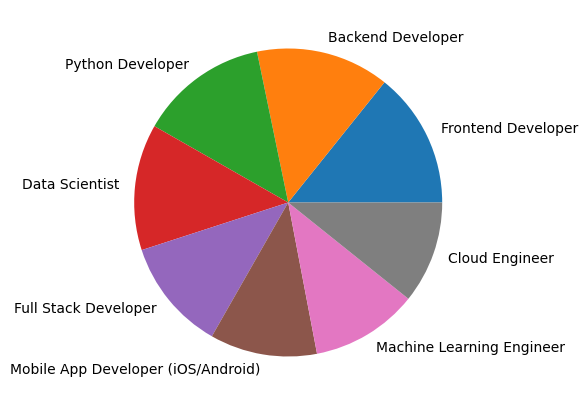

In [8]:
plt.figure(figsize=(15,5))
plt.pie(count,labels=label)

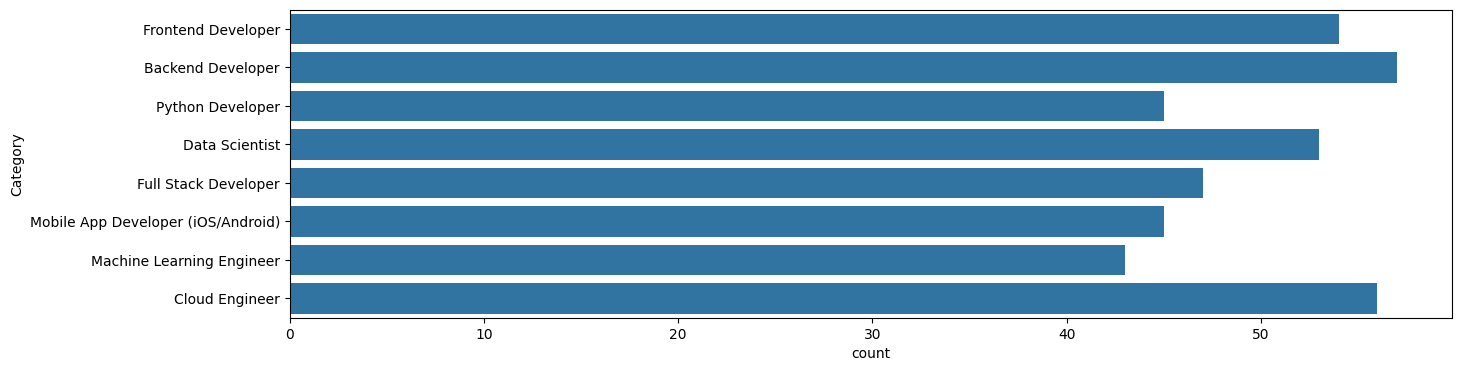

In [9]:
plt.figure(figsize=(15,4))
sns.countplot(data['Category'])
plt.show()

In [10]:
data['Category'][0]

'Frontend Developer'

In [11]:
data['Resume']

0      As a seasoned Frontend Developer, I have a pro...
1      With a solid background in Backend Development...
2      As a Python Developer, I leverage my expertise...
3      With a background in Data Science, I possess a...
4      Experienced Frontend Developer with a passion ...
                             ...                        
395    Dynamic Cloud Engineer specializing in archite...
396    Skilled Cloud Engineer with a focus on buildin...
397    Experienced Full Stack Developer with expertis...
398    Innovative Full Stack Developer with a passion...
399    Dynamic Full Stack Developer specializing in b...
Name: Resume, Length: 400, dtype: str

# Cleaning Data

Urls <br>
Hashtags <br>
Mentions <br>
Special Letters <br>
Punctuations <br>

In [12]:
import re

def CleanResume(txt):
    # Remove URLs
    txt = re.sub(r'http\S+', ' ', txt)
    
    # Remove hashtags
    txt = re.sub(r'#\S+', ' ', txt)
    
    # Remove mentions
    txt = re.sub(r'@\S+', ' ', txt)
    
    # Remove punctuations and special characters
    txt = re.sub(r'[^\w\s]', ' ', txt)
    
    # Remove extra spaces
    txt = re.sub(r'\s+', ' ', txt).strip()
    
    return txt

In [13]:
data['Resume'] = data['Resume'].apply(lambda x:CleanResume(x))

In [14]:
data['Resume']

0      As a seasoned Frontend Developer I have a prov...
1      With a solid background in Backend Development...
2      As a Python Developer I leverage my expertise ...
3      With a background in Data Science I possess a ...
4      Experienced Frontend Developer with a passion ...
                             ...                        
395    Dynamic Cloud Engineer specializing in archite...
396    Skilled Cloud Engineer with a focus on buildin...
397    Experienced Full Stack Developer with expertis...
398    Innovative Full Stack Developer with a passion...
399    Dynamic Full Stack Developer specializing in b...
Name: Resume, Length: 400, dtype: str

# Words Into Category

In [15]:
# data['Category']
data

,Category,Resume
0,Frontend Developer,As a seasoned Frontend Developer I have a prov...
1,Backend Developer,With a solid background in Backend Development...
2,Python Developer,As a Python Developer I leverage my expertise ...
3,Data Scientist,With a background in Data Science I possess a ...
4,Frontend Developer,Experienced Frontend Developer with a passion ...
...,...,...
395,Cloud Engineer,Dynamic Cloud Engineer specializing in archite...
396,Cloud Engineer,Skilled Cloud Engineer with a focus on buildin...
397,Full Stack Developer,Experienced Full Stack Developer with expertis...
398,Full Stack Developer,Innovative Full Stack Developer with a passion...


In [16]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [17]:
le.fit(data['Category'])
data['Category'] = le.transform(data['Category'])

In [18]:
# data.Category
data.Category.unique()

array([3, 0, 7, 2, 4, 6, 5, 1])

Frontend Developer',                  'Backend Developer',
                   'Python Developer',                     'Data Scientist',
               'Full Stack Developer', 'Mobile App Developer (iOS/Android)',
          'Machine Learning Engineer',                     'Cloud Engineer'

# Vectorization

In [19]:
data['Resume'][0]

'As a seasoned Frontend Developer I have a proven track record of crafting stunning and responsive user interfaces for web applications With over 5 years of experience I am proficient in HTML CSS and JavaScript and I have a deep understanding of modern frontend frameworks such as React Vue js and Angular I excel in translating design mockups into pixel perfect cross browser compatible UIs ensuring an optimal user experience across devices Additionally I am well versed in CSS preprocessors like Sass and LESS enabling me to write clean and maintainable stylesheets My passion for UI UX design drives me to stay updated with the latest trends and best practices in the industry allowing me to create visually appealing and intuitive interfaces that engage users I am a collaborative team player with excellent communication skills able to work closely with designers backend developers and stakeholders to deliver high quality frontend solutions on time and within budget'

its calculate the count of this

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words= 'english')

tfidf.fit(data['Resume'])
requiredtxt = tfidf.transform(data['Resume'])

In [21]:
requiredtxt

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 26294 stored elements and shape (400, 1118)>

# Splitting

In [22]:
from sklearn.model_selection import train_test_split
x_train , x_test, y_train, y_test = train_test_split(requiredtxt, data['Category'], test_size=0.33, random_state=42)

In [23]:
x_train.shape

(268, 1118)

In [24]:
x_test.shape

(132, 1118)

<h2>Now let's train the model and print the classification report: </h2>



In [25]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score

clf = OneVsRestClassifier(KNeighborsClassifier())
clf.fit(x_train,y_train)
y_pred = clf.predict(x_test)
# print(y_pred)
print(accuracy_score (y_test,y_pred))

0.9621212121212122


<h2>Prediction System</h2>

In [26]:
myresume = 'I am a motivated and detail-oriented B.Tech student specializing in Artificial Intelligence and Machine Learning, with strong analytical and problem-solving abilities. I have a solid foundation in programming languages such as C, C++, Python, and Java, along with a good understanding of data structures and algorithms. My knowledge extends to machine learning concepts, data analysis, and working with real-world datasets. I am proficient in tools like MS Excel, PowerPoint, and Word, and possess the ability to interpret data effectively. In addition, I have strong communication, teamwork, and time management skills, along with adaptability and a willingness to learn new technologies, enabling me to perform efficiently in dynamic environments.'

In [27]:
import pickle
pickle.dump(tfidf, open('tfidf.pkl','wb'))
pickle.dump(clf, open('clf.pkl', 'wb'))

In [31]:
import pickle

# load the train classifier
clf = pickle.load(open('clf.pkl', 'rb'))

# clean the input resume
Cleaned_Resume = CleanResume(myresume)

# transform the cleaned cleaned resume using the trained tfidfvectorizer
input_features =  tfidf.transform([Cleaned_Resume])

#  make the prediction using the loaded classifier
prediction_id =clf.predict(input_features)[0]

# print(prediction_id)

# map category id to category name
category_mapping = {
    3: 'Frontend Developer',
    0: 'Backend Developer',
    7: 'Python Developer',
    2: 'Data Scientist',
    4: 'Full Stack Developer',
    6:'Mobile App Developer (iOS/Android)',
    5: 'Machine Learning Engineer',
    1: 'Cloud Engineer'
}
category_name = category_mapping.get(prediction_id,"unkonown")

print("Predicted Category:", category_name)

Predicted Category: Data Scientist
